# Figure 3: Microbial transcriptomics

DEK and taxa contributions for CST III and CST IV Communities between bodysites and overtime

In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
import seaborn as sns
import random
import matplotlib.patches as mpatches
from sklearn.preprocessing import scale
from sklearn.decomposition import PCA
from Bio import Phylo
import os

## Importing/preprocessing annotations and setting some constants

In [52]:
# tresholds
FC_THRESH = 1
PVAL = 0.05
MAX_ZEROS = 0.75

In [53]:
#read in MT virgo2 gene counts, and preprocess
virgo2_mt_genes_raw = pd.read_csv('./fig3_datasets/taxa_filt_mmtm_mt_virgo2_NR_Taxa_051324_junk_removed.csv')

#read in the kegg annotations
virgo2_kegg_annots = pd.read_csv('./common/virgo2_files/8.VIRGO2.kegg.txt', sep='\t')

#merge
virgo2_mt_genes_raw = pd.merge(virgo2_mt_genes_raw, virgo2_kegg_annots[['PC', 'KEGG']], left_on='Gene', right_on='PC', how='left').drop(['Cat', 'PC'], axis=1)

#get rid of control columns
cols = ['Gene', 'Taxa', 'KEGG', 'Length']
cols.extend([c for c in virgo2_mt_genes_raw.columns if c.startswith('MT_')])
virgo2_mt_genes_raw = virgo2_mt_genes_raw[cols]

#get rid of the MT_ prefix
cols = ['Gene', 'Taxa', 'KEGG', 'Length']
cols.extend([c.split('_')[1] for c in virgo2_mt_genes_raw.columns[4:]])
virgo2_mt_genes_raw.columns = cols

#glcorr
glcorr_data = virgo2_mt_genes_raw[virgo2_mt_genes_raw.columns[4:]].div(virgo2_mt_genes_raw['Length'],axis=0)
virgo2_mt_genes_raw = pd.concat([virgo2_mt_genes_raw[virgo2_mt_genes_raw.columns[0:4]],glcorr_data],axis=1).drop('Length', axis=1)

#read in the MT cst assignments and sample metadata, and merge to a single file
sample_csts = pd.read_csv('./fig3_datasets/mmtm_mt_cst_assingments_06122024_renamed.csv')
sample_metadata = pd.read_csv('./common/mmtm_metadata.csv')

sample_metadata = pd.merge(sample_metadata, sample_csts, left_on='IGS LABEL', right_on='sampleID', how='right')


#read in the kegg ortholog to kegg pathways and kegg modules data
kegg_path = pd.read_csv('./common/kegg/ko/ko_pathway.list',sep='\t', header=None).rename(columns={0:'kegg', 1:'pathway'})
kegg_path['kegg'] = kegg_path['kegg'].astype(str).apply(lambda x:x.split(':')[1])
kegg_path['pathway'] = kegg_path['pathway'].astype(str).apply(lambda x:x.split(':')[1])

kegg_mod = pd.read_csv('./common/kegg/ko/ko_module.list',sep='\t', header=None).rename(columns={0:'kegg', 1:'module'})
kegg_mod['kegg'] = kegg_mod['kegg'].astype(str).apply(lambda x:x.split(':')[1])
kegg_mod['module'] = kegg_mod['module'].astype(str).apply(lambda x:x.split(':')[1])

kegg_path_defs = pd.read_csv('./common/kegg/pathway/parsed_pathway.csv')
kegg_path_defs = dict(zip(kegg_path_defs['pathway_id'], kegg_path_defs['description']))

kegg_mod_defs = pd.read_csv('./common/kegg/module/parsed_modules.csv')
kegg_mod_defs = dict(zip(kegg_mod_defs['kegg_module_id'], kegg_mod_defs['kegg_module_name']))

#read in parsed kegg functional groups and filter out all functional groups that aren't of interest
kegg_func_groups = pd.read_csv('./common/kegg/parsed_functional_groups_prok_manual_filt.csv', dtype=str)

#remove the brite specific annotations
kegg_func_groups = kegg_func_groups[~(kegg_func_groups['A_id'] == "09180")]

#preprocess these annotations so that there is 1 unique D_ID:B_ID pair
kegg_func_groups = kegg_func_groups.groupby(['D_id', 'B']).agg(lambda x: list(x.unique())).reset_index()


In [54]:
#preprocess gene abundance list

# get rid of genes that are more than X% 0s
virgo2_mt_genes = virgo2_mt_genes_raw[~((virgo2_mt_genes_raw[virgo2_mt_genes_raw.columns[3:]] == 0).sum(axis=1)/(virgo2_mt_genes_raw[virgo2_mt_genes_raw.columns[3:]].shape[1]) > MAX_ZEROS)]

#get rid of NA kegg annotations
virgo2_mt_genes = virgo2_mt_genes.dropna()

#set the annotations for genes with multiple KEGGS to the first one
virgo2_mt_genes['KEGG'] = virgo2_mt_genes['KEGG'].apply(lambda x: x.split(',')[0] if ',' in x else x)

In [55]:
#some global color schemes
my_cst_cmap = matplotlib.colors.ListedColormap(['#fe0308', '#86c61f','#ff7200','#448a73','#221886','#fae50d'])
my_timepoint_cmap = matplotlib.colors.ListedColormap(['#4d4f4e','#c2c4c2'])
my_cv_cmap = matplotlib.colors.ListedColormap(['#5924ed','#9fafe0'])
my_concord_cmap =  matplotlib.colors.ListedColormap(['#f5b216','#1bbabf', '#474973'])

bodysite_colors = {
    'C':'#5924ed',
    'V': '#9fafe0'
}

cst_colors = {
    'I':'#fe0308',
    'II':'#86c61f',
    'III':'#ff7200',
    'IV-A':'#448a73',
    'IV-B':'#221886',
    'IV-C':'#989898',
    'V':'#fae50d'
}

concord_colors = {
        0:'#f5b216',
        0.5:'#1bbabf',
        1:'#474973'
    }

#set up taxa color scheme
taxa_key = pd.read_csv('./common/VIRGO2_taxaKey.csv')
taxa_color_scheme = dict(zip(taxa_key.Taxa,taxa_key.Color))
taxa_text_legend = dict(zip(taxa_key.Taxa,taxa_key.Text))

def get_color(taxa):

    chars = '0123456789ABCDEF'

    if taxa in taxa_color_scheme:
        
        taxa_color = taxa_color_scheme[taxa]

    else:
        taxa_color_scheme[taxa] = '#'+''.join(random.sample(chars,6))
        taxa_color = taxa_color_scheme[taxa]

    return taxa_color

taxa_rename = {'Bifidobacterium_vaginale' : 'Gardnerella_vaginalis', 'UBA629_sp005465875':'Ca. L. vaginae', 'Bifidobacterium_swidsinskii':'Gardnerella_swidsinskii', 'Bifidobacterium_leopoldii':'Gardnerella_leopoldii', 'Bifidobacterium_piotii':'Gardnerella_piotii', 'KA00274_sp902373515':'Amygdalobacter_indicium', 'Bifidobacterium':'Gardnerella'}
def format_taxa_name(taxa):
    if taxa in taxa_rename:
        taxa = taxa_rename[taxa] 
    '''if taxa in taxa_text_legend.keys():
        return "$\it{%s}$" %(taxa_text_legend[taxa])'''
    to_return = []
    for p in taxa.split('_'):
        label="$\it{%s}$" %(p)
        to_return.append(label)
    return ' '.join(to_return)

#holds color scheme for B levels
b_level_colors = {"Other":"#acadac"}
b_level_colors ={'09101 Carbohydrate metabolism': '#0000ee',
 '09102 Energy metabolism': '#9933cc',
 '09103 Lipid metabolism': '#009999',
 '09104 Nucleotide metabolism': '#ff0000',
 '09105 Amino acid metabolism': '#ff9933',
 '09106 Metabolism of other amino acids': '#ff6600',
 '09107 Glycan biosynthesis and metabolism': '#3399ff',
 '09108 Metabolism of cofactors and vitamins': '#ff6699',
 '09109 Metabolism of terpenoids and polyketides': '#00cc33',
 '09110 Biosynthesis of other secondary metabolites': '#cc3366',
 '09111 Xenobiotics biodegradation and metabolism': '#ccaa99',
 '09121 Transcription': '#A002B8',
 '09122 Translation': '#01DCB9',
 '09123 Folding, sorting and degradation': '#38EA9C',
 '09124 Replication and repair': '#D59659',
 '09131 Membrane transport': '#D160EC',
 '09132 Signal transduction': '#A5E339',
 '09141 Transport and catabolism': '#AA14EA',
 '09142 Cell motility': '#7D0E87',
 '09143 Cell growth and death': '#93F24D',
 '09145 Cellular community - prokaryotes': '#0B0740',
 '09126 Chromosome': '#C9D832',
 '09159 Environmental adaptation': '#0D6F57',
 '09133 Signaling molecules and interaction': '#AE85B9'}

fdr_palette= {True:'#b4b6b8', False:'#e1e3e6'}

my_cmap = matplotlib.colors.LinearSegmentedColormap.from_list('_',['#ffff','#104E8B','#FF1493','#B22222'])


## Make Figure Layout

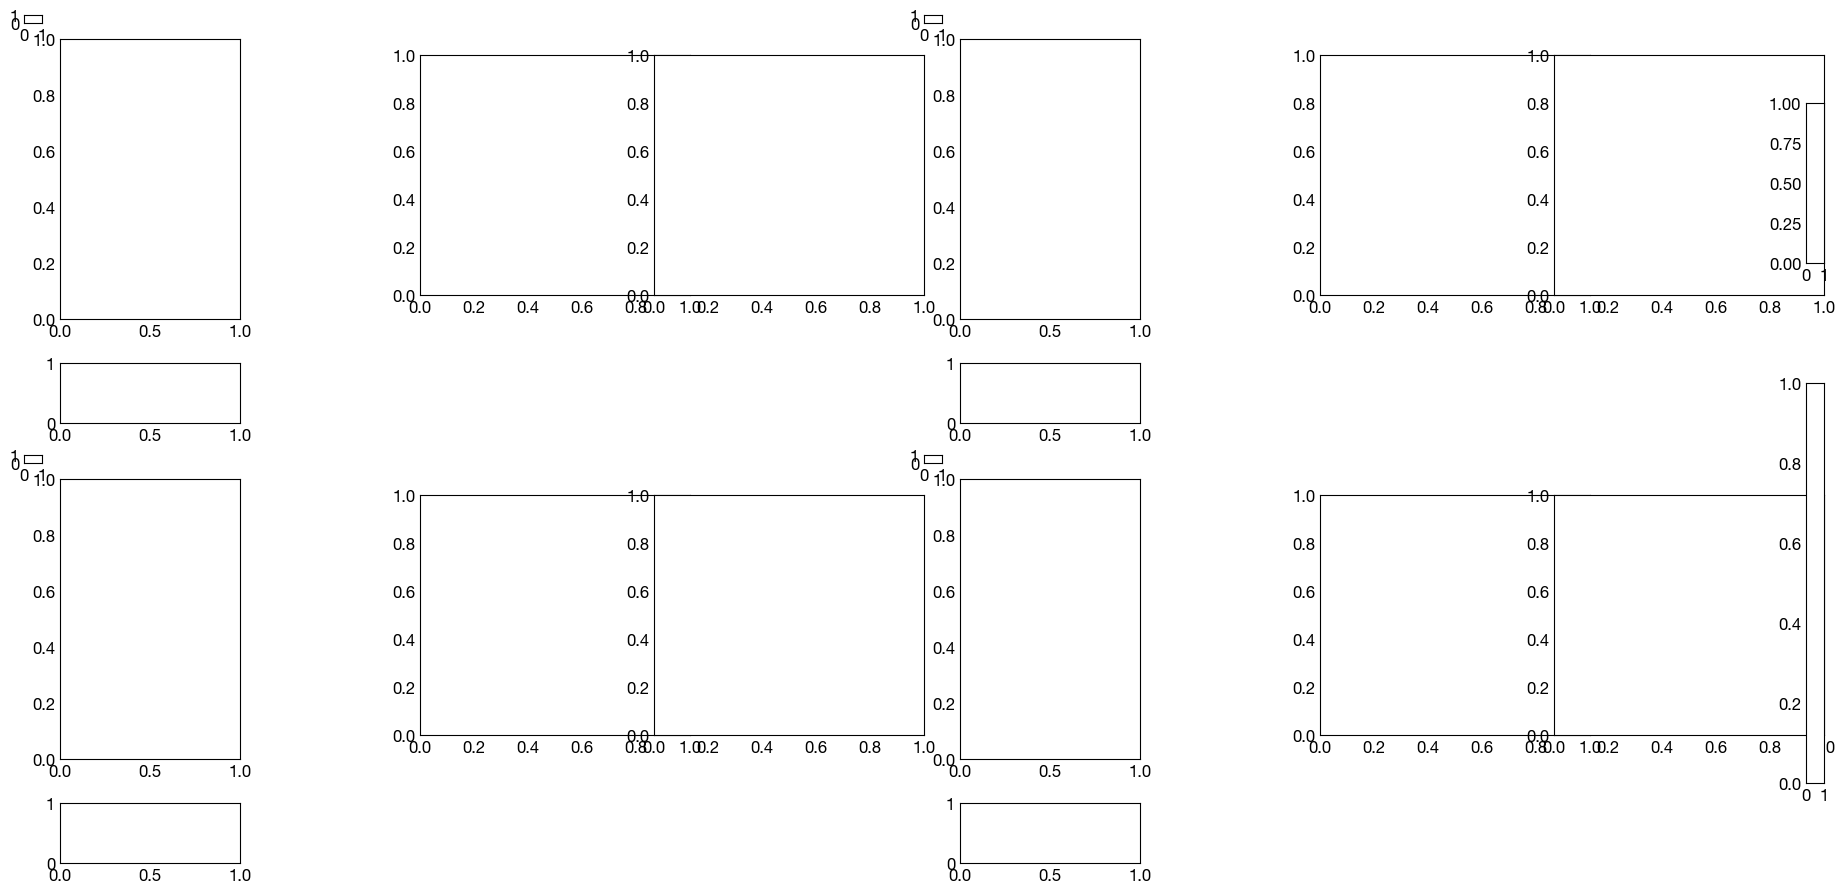

In [56]:
# figure size
WIDTH = 18
HEIGHT = 8

# figure style
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 12
plt.rcParams['xtick.major.size'] = 0
plt.rcParams['ytick.major.size'] = 0
plt.rcParams['pdf.fonttype'] = 42 # need this to open/edit in illustrator - if needed

fig = plt.figure(figsize=(WIDTH, HEIGHT))


### add the axes

# axes for cst III, cervix vs vagina
ax1_1 = fig.add_axes([0.05, 0.68, 0.1, 0.35])
ax1_2 = fig.add_axes([0.05, 0.55, 0.1, 0.075])
ax1_3 = fig.add_axes([0.25, 0.71, 0.15, 0.3])
ax1_4 = fig.add_axes([0.38, 0.71, 0.15, 0.3])

# axes for cst IV, cervix vs vagina
ax2_1 = fig.add_axes([0.55, 0.68, 0.1, 0.35])
ax2_2 = fig.add_axes([0.55, 0.55, 0.1, 0.075])
ax2_3 = fig.add_axes([0.75, 0.71, 0.15, 0.3])
ax2_4 = fig.add_axes([0.88, 0.71, 0.15, 0.3])

# axes for cst III, overtime
ax3_1 = fig.add_axes([0.05, 0.13, 0.1, 0.35])
ax3_2 = fig.add_axes([0.05, 0, 0.1, 0.075])
ax3_3 = fig.add_axes([0.25, 0.16, 0.15, 0.3])
ax3_4 = fig.add_axes([0.38, 0.16, 0.15, 0.3])

# axes for cst IV, overtime
ax4_1 = fig.add_axes([0.55, 0.13, 0.1, 0.35])
ax4_2 = fig.add_axes([0.55, 0, 0.1, 0.075])
ax4_3 = fig.add_axes([0.75, 0.16, 0.15, 0.3])
ax4_4 = fig.add_axes([0.88, 0.16, 0.15, 0.3])

# axis for functions legend
func_legend_ax = fig.add_axes([1.02, 0.1, 0.01, 0.5])

# axis for colorbar
cbar_ax =  fig.add_axes([1.02, 0.75, 0.01, 0.2])

# axes for figure labels
a_ax = fig.add_axes([0.03, 1.05, 0.01, 0.01])
b_ax = fig.add_axes([0.53, 1.05, 0.01, 0.01])
c_ax = fig.add_axes([0.03, 0.5, 0.01, 0.01])
d_ax = fig.add_axes([0.53, 0.5, 0.01, 0.01])

## CST III, cervix vs vagina

In [57]:
#cervix vs vagina CST III
dek = pd.read_csv('./fig3_datasets/mmtm_mt_diff_micro_kegg_cervix-vagina_cstIII_deseq2.csv')
dek['row'] = dek['row'].apply(lambda x: x.split(',')[0] if ',' in x else x)

#filter results for the significant hits
dek['sig'] = (dek['padj'] <= PVAL) & (abs(dek['log2FoldChange']) >= FC_THRESH)
dek['log10padj'] = -1*np.log10(dek['padj'])

#merge the pathway and module annotations
dek = pd.merge(dek, kegg_mod, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_path, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_func_groups, left_on='row', right_on='D_id').drop(columns='D_id')

#record whether or not each row is present in the preprocessed relative abundance table
dek['prev_thresh'] = dek['row'].apply(lambda x: x in virgo2_mt_genes['KEGG'].values)
dek = dek.dropna().drop(['lfcSE', 'stat', 'baseMean'], axis=1)

In [58]:
#plot the volcano plot
ax = ax1_1
sns.scatterplot(data=dek[dek.sig == False], x='log2FoldChange', y='log10padj', hue='sig', palette=fdr_palette, legend=False, s=30, linewidth=0,  ax=ax)
sns.scatterplot(data=dek[(dek.sig == True) & (dek.prev_thresh == True)], x='log2FoldChange', y='log10padj', hue='B', palette=b_level_colors, legend=False, s=30, alpha=0.9, linewidth=1, edgecolor='black', ax=ax)

ax.set_title('CST III:\nCervix vs. Vagina')
ax.set_xlabel('$log_{2}FC$')
ax.set_ylabel('$-log_{10}(p-value)$')
xbound = max(abs(dek['log2FoldChange']))
ax.set_xbound((-1.25*xbound, 1.25*xbound))

ax.text(x=1.25, y=0, s=' ↑Cervix', fontsize=8, ha='left', fontfamily='Arial')
ax.text(x=-1.25, y=0, s='↑Vagina ', fontsize=8, ha='right', fontfamily='Arial')


#plot the pathway counts
ax = ax1_2
ax.set_yscale('log')
xbound = 30
ax.set_xbound(-1*xbound,xbound)
bar_width=0.5

to_bar_plot = dek[(dek.sig == True) & (dek.prev_thresh == True)]
loc_abs = 0
for b_path, bdata in to_bar_plot.groupby('B'):
    bcolor = b_level_colors[b_path]

    #plot the negative side first
    temp = bdata[bdata['log2FoldChange'] < 0]
    ax.bar(x=-1*(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    #plot the positive side
    temp = bdata[bdata['log2FoldChange'] > 0]
    ax.bar(x=(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    loc_abs += 1


ax.set_xticklabels('')
ax.set_ylim((1, 500))
ax.set_ylabel('Counts')

for ax in [ax1_1, ax1_2]:
    ax.axvline(x=0, color='black', alpha=0.3, linestyle='--', linewidth=0.3)

In [ ]:
### make the heatmaps

#holds the final results
data_func_taxas = {'taxa':[], 'b_func':[], 'average_rel_contr':[], 'group':[]}

### cervix analysis

#pull the samples from cervix
data = list(sample_metadata[(sample_metadata['CST'] == 'III') & (sample_metadata['Cervix/Vagina'] == 'C')]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange > 0)]['row'])] 

#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)

cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the cervix
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['C' for _ in range(len(tdata))])

### vagina analysis
#pull the samples from vagina
data = list(sample_metadata[(sample_metadata['CST'] == 'III') & (sample_metadata['Cervix/Vagina'] == 'V')]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange < 0)]['row'])] 

#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)

cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the vagina
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['V' for _ in range(len(tdata))])

data_func_taxas = pd.DataFrame(data_func_taxas)
data_func_taxas = data_func_taxas.pivot_table(columns='b_func', values='average_rel_contr', index=['taxa', 'group']).reset_index().fillna(0)

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/772115239.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/772115239.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)


Text(0.5, 1.0, 'Cervix')

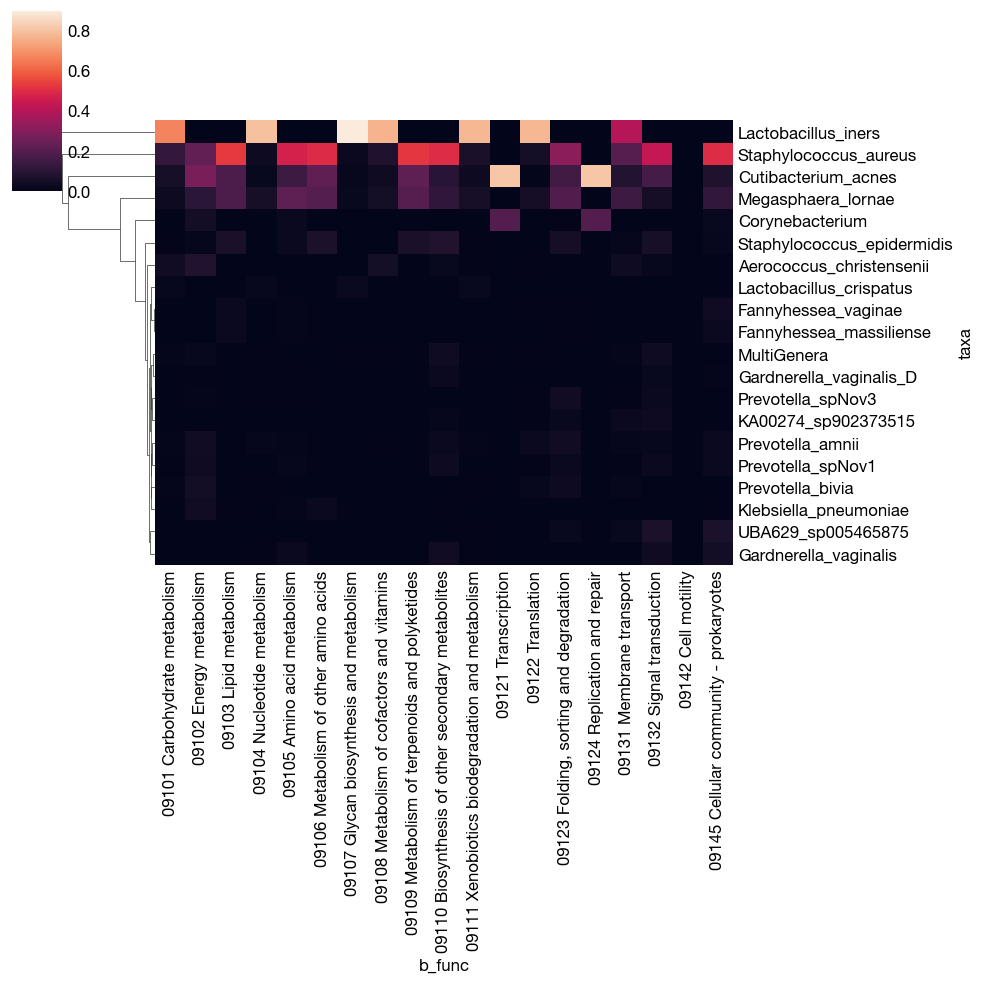

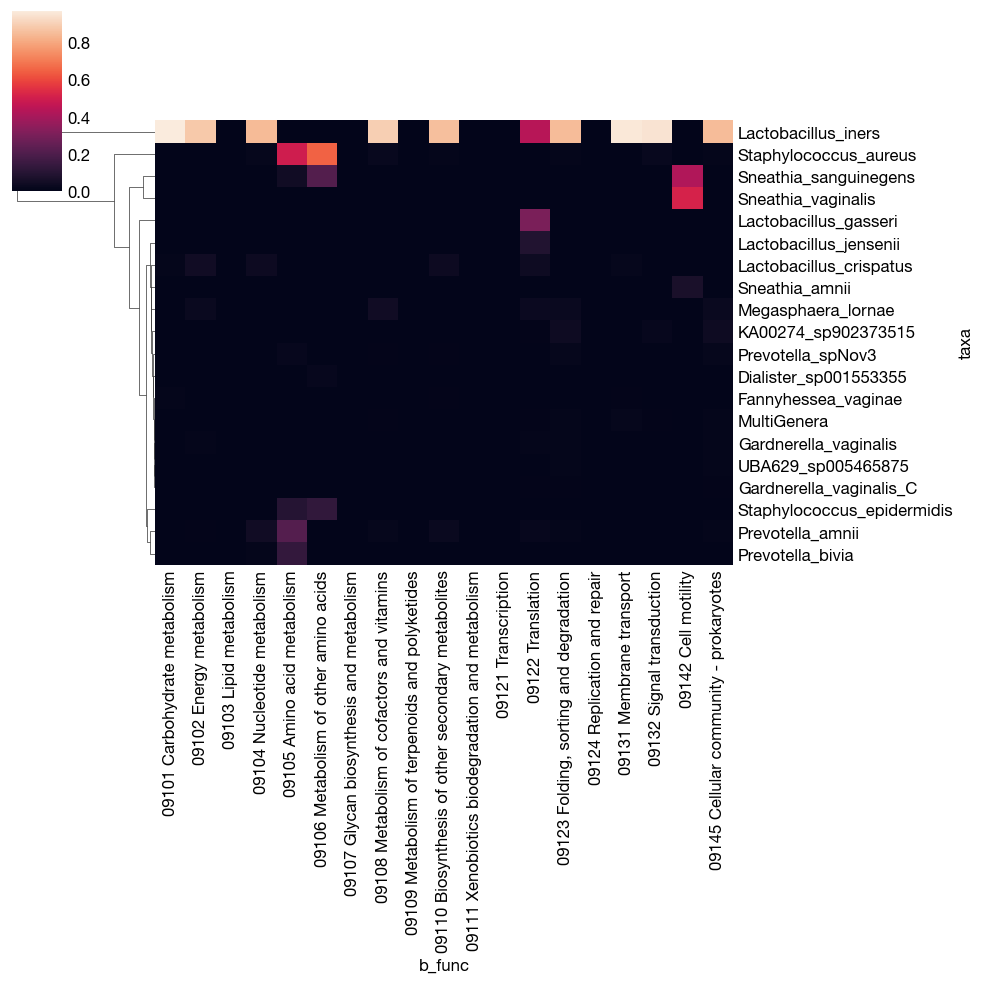

In [60]:
axs = [ax1_3, ax1_4]

ax_pos = 0
num_to_plot = 20
for g in ['V', 'C']:
    ax = axs[ax_pos]

    #get the data for this group
    plot_data =  data_func_taxas[data_func_taxas['group'] == g]
    plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
    plot_data = plot_data.sort_values(by='sum', ascending=False)[0:num_to_plot]

    

    plot_data = sns.clustermap(plot_data.set_index('taxa').iloc[:,1:-1], col_cluster=False).data2d

    sns.heatmap(plot_data.T, ax=ax, cmap=my_cmap, linewidths=0.3, linecolor='#d4d2d3', xticklabels=True, yticklabels=True)
    
    ax.set_xlabel('')
    ax.set_ylabel('')

    #ax.set_xticklabels([' '.join(l.get_text().split('_')) for l in ax.get_xticklabels()])
    #ax.set_xticklabels(["$\it{%s}$" % l.get_text() for l in ax.get_xticklabels()])
    ax.set_xticklabels([format_taxa_name(l.get_text()) for l in ax.get_xticklabels()], fontsize=6.25)
    ax.collections[0].colorbar.remove()
    ax.set_xlim(0,num_to_plot)

    ax_pos += 1


axs[1].set_yticklabels(['' for _ in axs[1].get_yticklabels()])
axs[0].set_yticklabels([' '.join(l.get_text().split(' ')[1:]) for l in axs[0].get_yticklabels()], fontsize=6.25)

axs[0].set_title('Vagina' ,fontsize=10)
axs[1].set_title('Cervix', fontsize=10)


## CST IV, cervix vs vagina

In [61]:
#cervix vs vagina CST III
dek = pd.read_csv('./fig3_datasets/mmtm_mt_diff_micro_kegg_cervix-vagina_cstIV_deseq2.csv')
dek['row'] = dek['row'].apply(lambda x: x.split(',')[0] if ',' in x else x)

#filter results for the significant hits
dek['sig'] = (dek['padj'] <= PVAL) & (abs(dek['log2FoldChange']) >= FC_THRESH)
dek['log10padj'] = -1*np.log10(dek['padj'])

#merge the pathway and module annotations
dek = pd.merge(dek, kegg_mod, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_path, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_func_groups, left_on='row', right_on='D_id').drop(columns='D_id')

#record whether or not each row is present in the preprocessed relative abundance table
dek['prev_thresh'] = dek['row'].apply(lambda x: x in virgo2_mt_genes['KEGG'].values)
dek = dek.dropna().drop(['lfcSE', 'stat', 'baseMean'], axis=1)

In [62]:
#plot the volcano plot
ax = ax2_1
sns.scatterplot(data=dek[dek.sig == False], x='log2FoldChange', y='log10padj', hue='sig', palette=fdr_palette, legend=False, s=30, linewidth=0,  ax=ax)
sns.scatterplot(data=dek[(dek.sig == True) & (dek.prev_thresh == True)], x='log2FoldChange', y='log10padj', hue='B', palette=b_level_colors, legend=False, s=30, alpha=0.9, linewidth=1, edgecolor='black', ax=ax)

ax.set_title('CST IV:\nCervix vs. Vagina')
ax.set_xlabel('$log_{2}FC$')
ax.set_ylabel('$-log_{10}(p-value)$')
xbound = max(abs(dek['log2FoldChange']))
ax.set_xbound((-1.25*xbound, 1.25*xbound))

ax.text(x=1.25, y=0, s=' ↑Cervix', fontsize=8, ha='left', fontfamily='Arial')
ax.text(x=-1.25, y=0, s='↑Vagina ', fontsize=8, ha='right', fontfamily='Arial')

#plot the pathway counts
ax = ax2_2
ax.set_yscale('log')
xbound = 30
ax.set_xbound(-1*xbound,xbound)
bar_width=0.5

to_bar_plot = dek[(dek.sig == True) & (dek.prev_thresh == True)]
loc_abs = 0
for b_path, bdata in to_bar_plot.groupby('B'):
    bcolor = b_level_colors[b_path]

    #plot the negative side first
    temp = bdata[bdata['log2FoldChange'] < 0]
    ax.bar(x=-1*(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    #plot the positive side
    temp = bdata[bdata['log2FoldChange'] > 0]
    ax.bar(x=(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    loc_abs += 1


ax.set_xticklabels('')
ax.set_ylim((1, 500))
ax.set_ylabel('Counts')

for ax in [ax2_1, ax2_2]:
    ax.axvline(x=0, color='black', alpha=0.3, linestyle='--', linewidth=0.3)

In [ ]:
### make the heatmaps

#holds the final results
data_func_taxas = {'taxa':[], 'b_func':[], 'average_rel_contr':[], 'group':[]}

### cervix analysis

#pull the samples from cervix
data = list(sample_metadata[(sample_metadata['CST'].isin(['IV-A', 'IV-B', 'IV-C'])) & (sample_metadata['Cervix/Vagina'] == 'C')]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange > 0)]['row'])] 

#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)

cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the cervix
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['C' for _ in range(len(tdata))])

### vagina analysis
#pull the samples from vagina
data = list(sample_metadata[(sample_metadata['CST'].isin(['IV-A', 'IV-B', 'IV-C'])) & (sample_metadata['Cervix/Vagina'] == 'V')]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange < 0)]['row'])] 


#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)

cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the vagina
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['V' for _ in range(len(tdata))])

data_func_taxas = pd.DataFrame(data_func_taxas)
data_func_taxas = data_func_taxas.pivot_table(columns='b_func', values='average_rel_contr', index=['taxa', 'group']).reset_index().fillna(0)

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/3715027429.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/3715027429.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)


Text(0.5, 1.0, 'Cervix')

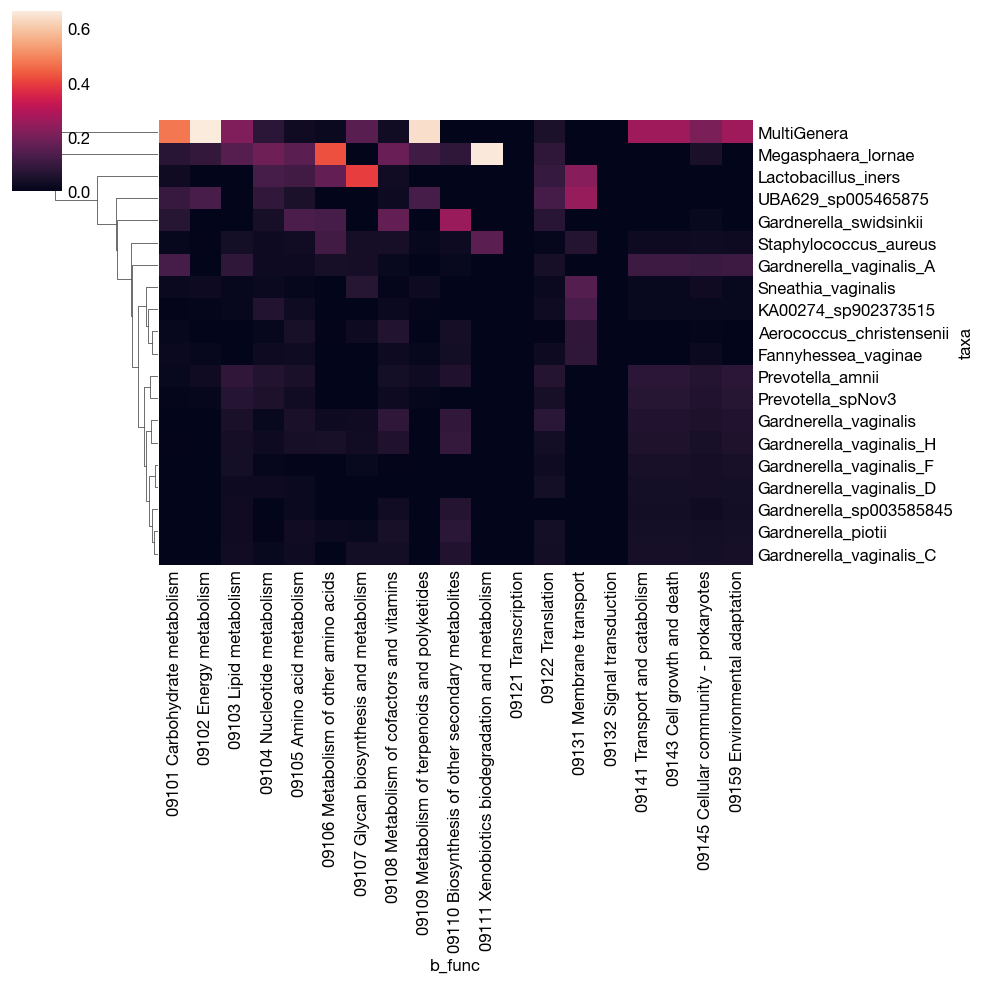

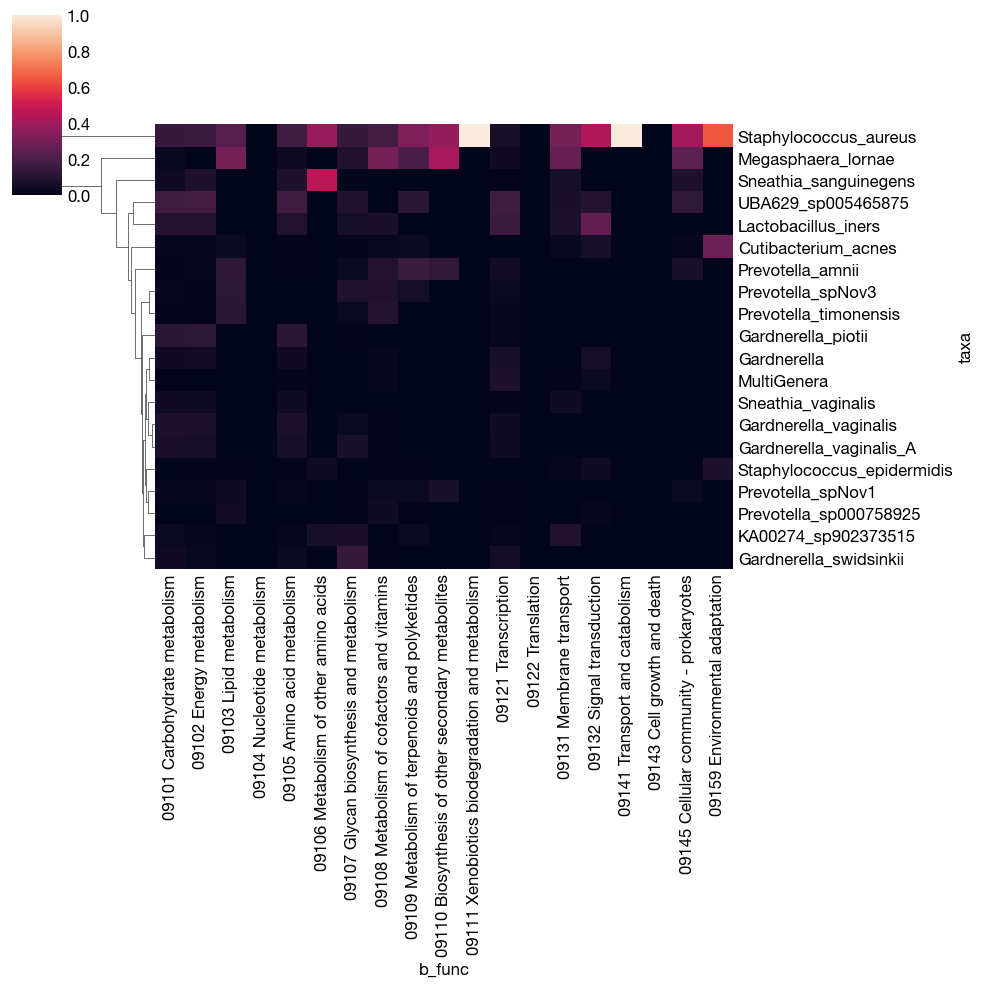

In [64]:
axs = [ax2_3, ax2_4]

ax_pos = 0
num_to_plot = 20
for g in ['V', 'C']:
    ax = axs[ax_pos]

    #get the data for this group
    plot_data =  data_func_taxas[data_func_taxas['group'] == g]
    plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
    plot_data = plot_data.sort_values(by='sum', ascending=False)[0:num_to_plot]

    plot_data = sns.clustermap(plot_data.set_index('taxa').iloc[:,1:-1], col_cluster=False).data2d

    sns.heatmap(plot_data.T, ax=ax, cmap=my_cmap, linewidths=0.3, linecolor='#d4d2d3', xticklabels=True, yticklabels=True)
    
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels([format_taxa_name(l.get_text()) for l in ax.get_xticklabels()], fontsize=6.25)
    ax.collections[0].colorbar.remove()

    ax_pos += 1


axs[1].set_yticklabels(['' for _ in axs[1].get_yticklabels()])
axs[0].set_yticklabels([' '.join(l.get_text().split(' ')[1:]) for l in axs[0].get_yticklabels()], fontsize=6.25)

axs[0].set_title('Vagina', fontsize=10)
axs[1].set_title('Cervix', fontsize=10)

## CST III, overtime

In [65]:
#overtime CST III
dek = pd.read_csv('./fig3_datasets/mmtm_mt_diff_micro_kegg_overtime_cstIII_deseq2.csv')
dek['row'] = dek['row'].apply(lambda x: x.split(',')[0] if ',' in x else x)

#filter results for the significant hits
dek['sig'] = (dek['padj'] <= PVAL) & (abs(dek['log2FoldChange']) >= FC_THRESH)
dek['log10padj'] = -1*np.log10(dek['padj'])

#merge the pathway and module annotations
dek = pd.merge(dek, kegg_mod, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_path, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_func_groups, left_on='row', right_on='D_id').drop(columns='D_id')

#record whether or not each row is present in the preprocessed relative abundance table
dek['prev_thresh'] = dek['row'].apply(lambda x: x in virgo2_mt_genes['KEGG'].values)
dek = dek.dropna().drop(['lfcSE', 'stat', 'baseMean'], axis=1)

In [66]:
#plot the volcano plot
ax = ax3_1
sns.scatterplot(data=dek[dek.sig == False], x='log2FoldChange', y='log10padj', hue='sig', palette=fdr_palette, legend=False, s=30, linewidth=0,  ax=ax)
sns.scatterplot(data=dek[(dek.sig == True) & (dek.prev_thresh == True)], x='log2FoldChange', y='log10padj', hue='B', palette=b_level_colors, legend=False, s=30, alpha=0.9, linewidth=1, edgecolor='black', ax=ax)

ax.set_title('CST III: Overtime')
ax.set_xlabel('$log_{2}FC$')
ax.set_ylabel('$-log_{10}(p-value)$')
xbound = max(abs(dek['log2FoldChange']))
ax.set_xbound((-1.25*xbound, 1.25*xbound))

ax.text(x=0.75, y=0, s=' ↑Timepoint 1', fontsize=8, ha='left', fontfamily='Arial')
ax.text(x=-0.75, y=0, s='↑Timepoint 2 ', fontsize=8, ha='right', fontfamily='Arial')

#plot the pathway counts
ax = ax3_2
ax.set_yscale('log')
xbound = 30
ax.set_xbound(-1*xbound,xbound)
bar_width=0.5

to_bar_plot = dek[(dek.sig == True) & (dek.prev_thresh == True)]
loc_abs = 0
for b_path, bdata in to_bar_plot.groupby('B'):
    bcolor = b_level_colors[b_path]

    #plot the negative side first
    temp = bdata[bdata['log2FoldChange'] < 0]
    ax.bar(x=-1*(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    #plot the positive side
    temp = bdata[bdata['log2FoldChange'] > 0]
    ax.bar(x=(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    loc_abs += 1


ax.set_xticklabels('')
ax.set_ylim((1, 500))
ax.set_ylabel('Counts')

for ax in [ax3_1, ax3_2]:
    ax.axvline(x=0, color='black', alpha=0.3, linestyle='--', linewidth=0.3)

In [ ]:
### make the heatmaps

#holds the final results
data_func_taxas = {'taxa':[], 'b_func':[], 'average_rel_contr':[], 'group':[]}

### tp1 analysis

#pull the samples from tp1
data = list(sample_metadata[(sample_metadata['CST'] == 'III') & (sample_metadata['Timepoint'] == 1)]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange > 0)]['row'])] 

#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)

cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the tp1
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['tp1' for _ in range(len(tdata))])

### tp2 analysis
#pull the samples from vagina
data = list(sample_metadata[(sample_metadata['CST'] == 'III') & (sample_metadata['Timepoint'] == 2)]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange < 0)]['row'])] 

#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)

cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the tp2
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['tp2' for _ in range(len(tdata))])

data_func_taxas = pd.DataFrame(data_func_taxas)
data_func_taxas = data_func_taxas.pivot_table(columns='b_func', values='average_rel_contr', index=['taxa', 'group']).reset_index().fillna(0)

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/830017360.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/830017360.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)


Text(0.5, 1.0, 'Timepoint 1')

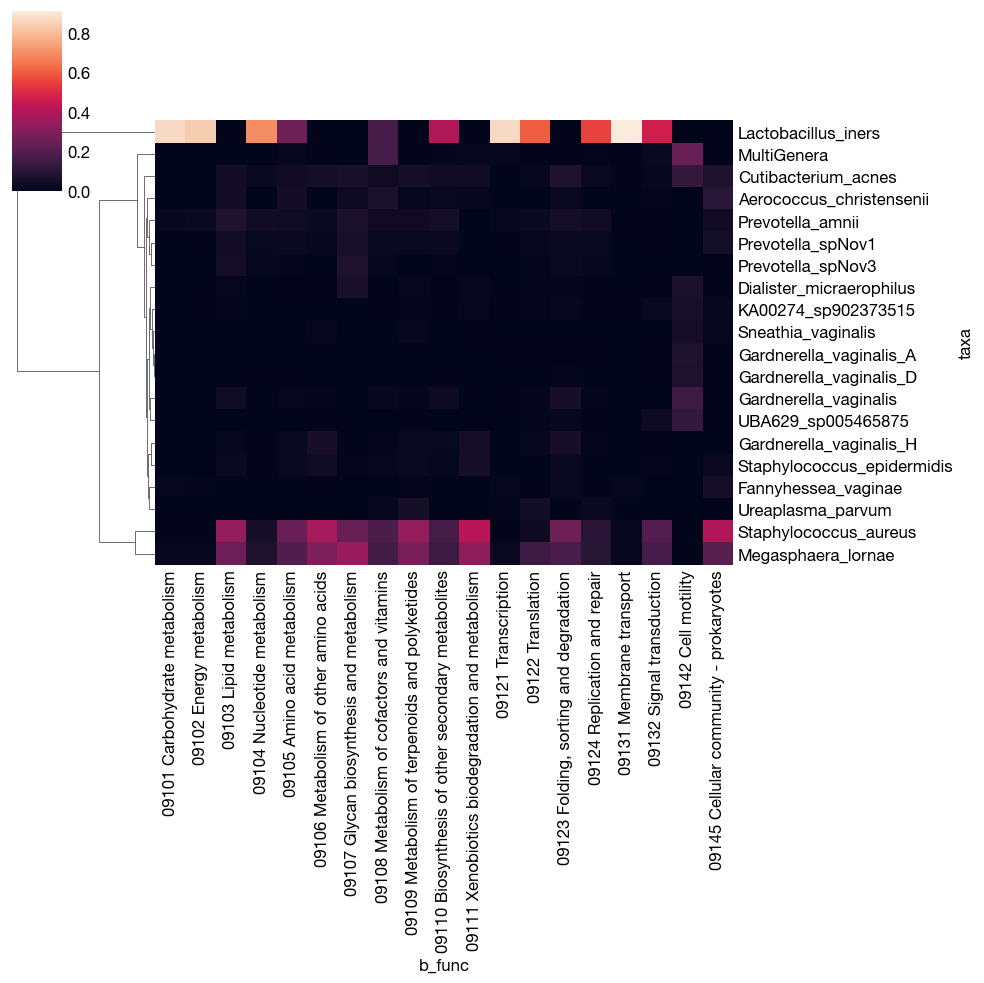

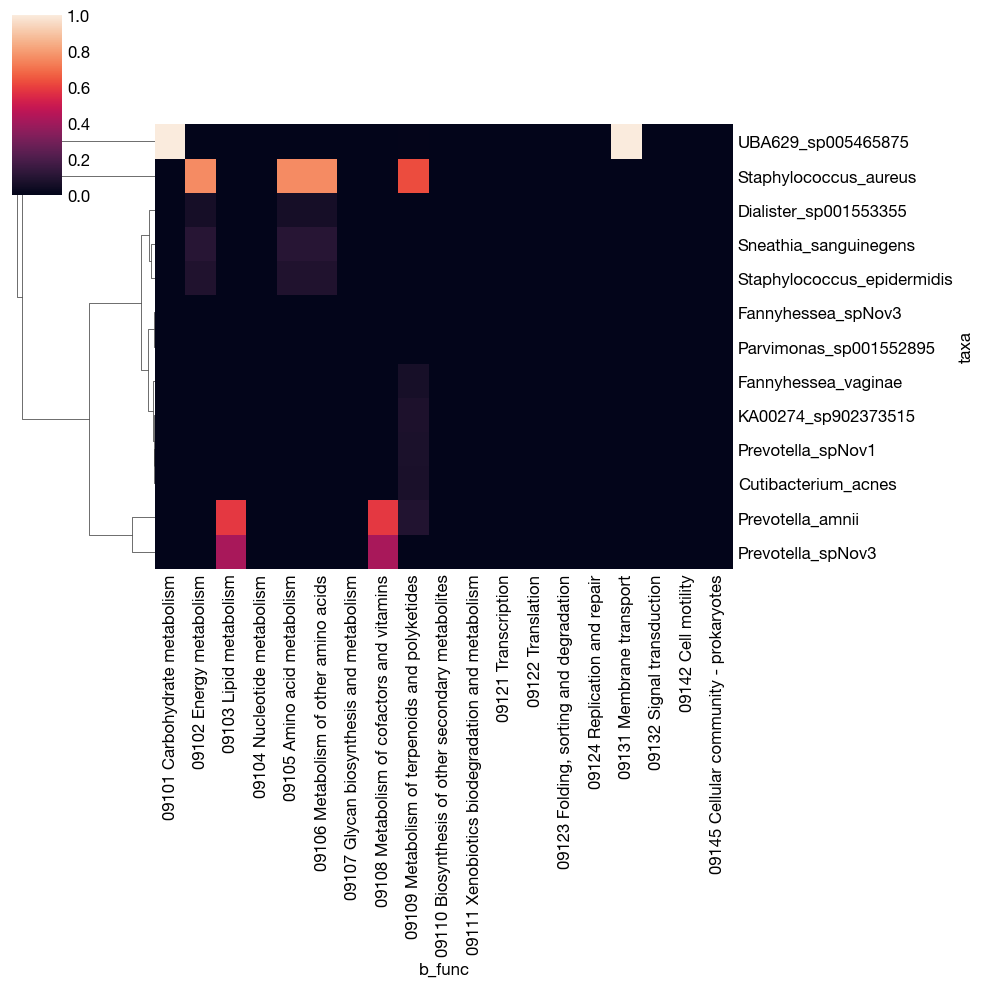

In [68]:
axs = [ax3_3, ax3_4]

ax_pos = 0
num_to_plot = 20
for g in ['tp2', 'tp1']:
    ax = axs[ax_pos]

    #get the data for this group
    plot_data =  data_func_taxas[data_func_taxas['group'] == g]
    plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
    plot_data = plot_data.sort_values(by='sum', ascending=False)[0:num_to_plot]

    plot_data = sns.clustermap(plot_data.set_index('taxa').iloc[:,1:-1], col_cluster=False).data2d

    sns.heatmap(plot_data.T, ax=ax, cmap=my_cmap, linewidths=0.3, linecolor='#d4d2d3', xticklabels=True, yticklabels=True)
    
    ax.set_xlabel('')
    ax.set_ylabel('')

    ax.set_xticklabels([format_taxa_name(l.get_text()) for l in ax.get_xticklabels()], fontsize=6.25)
    ax.collections[0].colorbar.remove()

    ax_pos += 1


axs[1].set_yticklabels(['' for _ in axs[1].get_yticklabels()])
axs[0].set_yticklabels([' '.join(l.get_text().split(' ')[1:]) for l in axs[0].get_yticklabels()], fontsize=6.25)


axs[0].set_title('Timepoint 2', fontsize=10)
axs[1].set_title('Timepoint 1', fontsize=10)

## CST IV, overtime

In [69]:
#overtime CST IV
dek = pd.read_csv('./fig3_datasets/mmtm_mt_diff_micro_kegg_overtime_cstIV_deseq2.csv')
dek['row'] = dek['row'].apply(lambda x: x.split(',')[0] if ',' in x else x)

#filter results for the significant hits
dek['sig'] = (dek['padj'] <= PVAL) & (abs(dek['log2FoldChange']) >= FC_THRESH)
dek['log10padj'] = -1*np.log10(dek['padj'])

#merge the pathway and module annotations
dek = pd.merge(dek, kegg_mod, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_path, left_on='row', right_on='kegg', how='left').drop(columns='kegg')
dek = pd.merge(dek, kegg_func_groups, left_on='row', right_on='D_id').drop(columns='D_id')

#record whether or not each row is present in the preprocessed relative abundance table
dek['prev_thresh'] = dek['row'].apply(lambda x: x in virgo2_mt_genes['KEGG'].values)
dek = dek.dropna().drop(['lfcSE', 'stat', 'baseMean'], axis=1)

In [70]:
#plot the volcano plot
ax = ax4_1
sns.scatterplot(data=dek[dek.sig == False], x='log2FoldChange', y='log10padj', hue='sig', palette=fdr_palette, legend=False, s=30, linewidth=0,  ax=ax)
sns.scatterplot(data=dek[(dek.sig == True) & (dek.prev_thresh == True)], x='log2FoldChange', y='log10padj', hue='B', palette=b_level_colors, legend=False, s=30, alpha=0.9, linewidth=1, edgecolor='black', ax=ax)

ax.set_title('CST IV: Overtime')
ax.set_xlabel('$log_{2}FC$')
ax.set_ylabel('$-log_{10}(p-value)$')
xbound = max(abs(dek['log2FoldChange']))
ax.set_xbound((-1.25*xbound, 1.25*xbound))

ax.text(x=0.75, y=0, s=' ↑Timepoint 1', fontsize=8, ha='left', fontfamily='Arial')
ax.text(x=-0.75, y=0, s='↑Timepoint 2 ', fontsize=8, ha='right', fontfamily='Arial')

#plot the pathway counts
ax = ax4_2
ax.set_yscale('log')
xbound = 30
ax.set_xbound(-1*xbound,xbound)
bar_width=0.5

to_bar_plot = dek[(dek.sig == True) & (dek.prev_thresh == True)]
loc_abs = 0
for b_path, bdata in to_bar_plot.groupby('B'):
    bcolor = b_level_colors[b_path]

    #plot the negative side first
    temp = bdata[bdata['log2FoldChange'] < 0]
    ax.bar(x=-1*(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    #plot the positive side
    temp = bdata[bdata['log2FoldChange'] > 0]
    ax.bar(x=(xbound - loc_abs), width=bar_width, height=len(temp), color=bcolor)

    loc_abs += 1


ax.set_xticklabels('')
ax.set_ylim((1, 500))
ax.set_ylabel('Counts')

for ax in [ax4_1, ax4_2]:
    ax.axvline(x=0, color='black', alpha=0.3, linestyle='--', linewidth=0.3)


In [ ]:
### make the heatmaps

#holds the final results
data_func_taxas = {'taxa':[], 'b_func':[], 'average_rel_contr':[], 'group':[]}

### tp1 analysis

#pull the samples from tp1
data = list(sample_metadata[(sample_metadata['CST'].isin(['IV-A', 'IV-B', 'IV-C'])) & (sample_metadata['Timepoint'] == 1)]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange > 0)]['row'])] 

#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)


cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the tp1
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['tp1' for _ in range(len(tdata))])

### tp2 analysis
#pull the samples from vagina
data = list(sample_metadata[(sample_metadata['CST'].isin(['IV-A', 'IV-B', 'IV-C'])) & (sample_metadata['Timepoint'] == 2)]['IGS LABEL'].values)

data = virgo2_mt_genes[['Gene', 'Taxa', 'KEGG'] + (data)]

#filter out to the ones that were dek (significantly)
data = data[data['KEGG'].isin(dek[(dek.sig == True) & (dek.prev_thresh == True) & (dek.log2FoldChange < 0)]['row'])] 

#merge with the functional info
data = pd.merge(data, kegg_func_groups[['D_id', 'B']], left_on='KEGG', right_on='D_id', how='left').drop('D_id', axis=1)

cols = ['B', 'Taxa']
cols.extend(data.columns[3:-1])
data = data[cols]

#calculate the relative contirbutions in the tp2
for b, bdata in data.groupby('B'):
    tdata = bdata.groupby('Taxa').sum(numeric_only=True)
    tdata = tdata.div(tdata.sum(axis=0),axis=1).reset_index()
    tdata['average'] = tdata.mean(axis=1, numeric_only=True)
    tdata = tdata[['Taxa', 'average']]
    
    data_func_taxas['taxa'].extend(tdata['Taxa'].values)
    data_func_taxas['average_rel_contr'].extend(tdata['average'].values)
    data_func_taxas['b_func'].extend([b for _ in range(len(tdata))])
    data_func_taxas['group'].extend(['tp2' for _ in range(len(tdata))])

data_func_taxas = pd.DataFrame(data_func_taxas)
data_func_taxas = data_func_taxas.pivot_table(columns='b_func', values='average_rel_contr', index=['taxa', 'group']).reset_index().fillna(0)

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/2246928051.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/2246928051.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)


Text(0.5, 1.0, 'Timepoint 1')

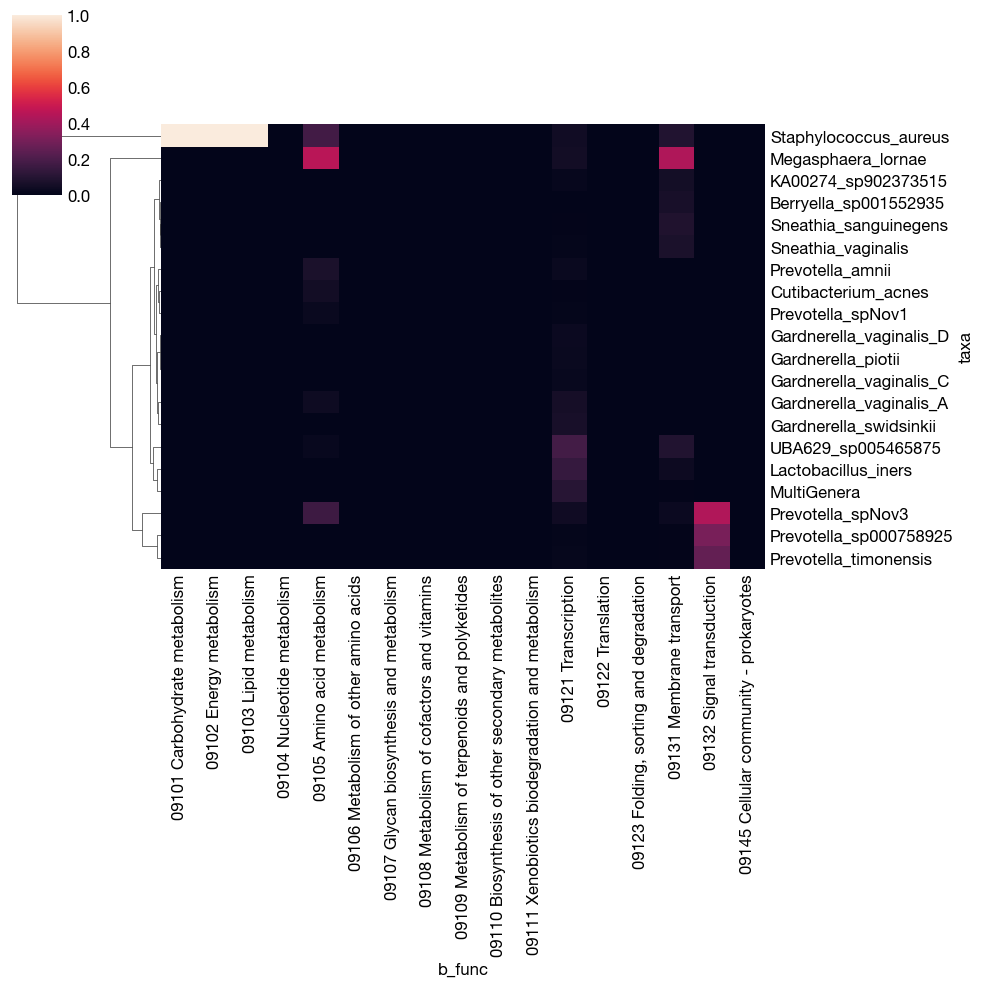

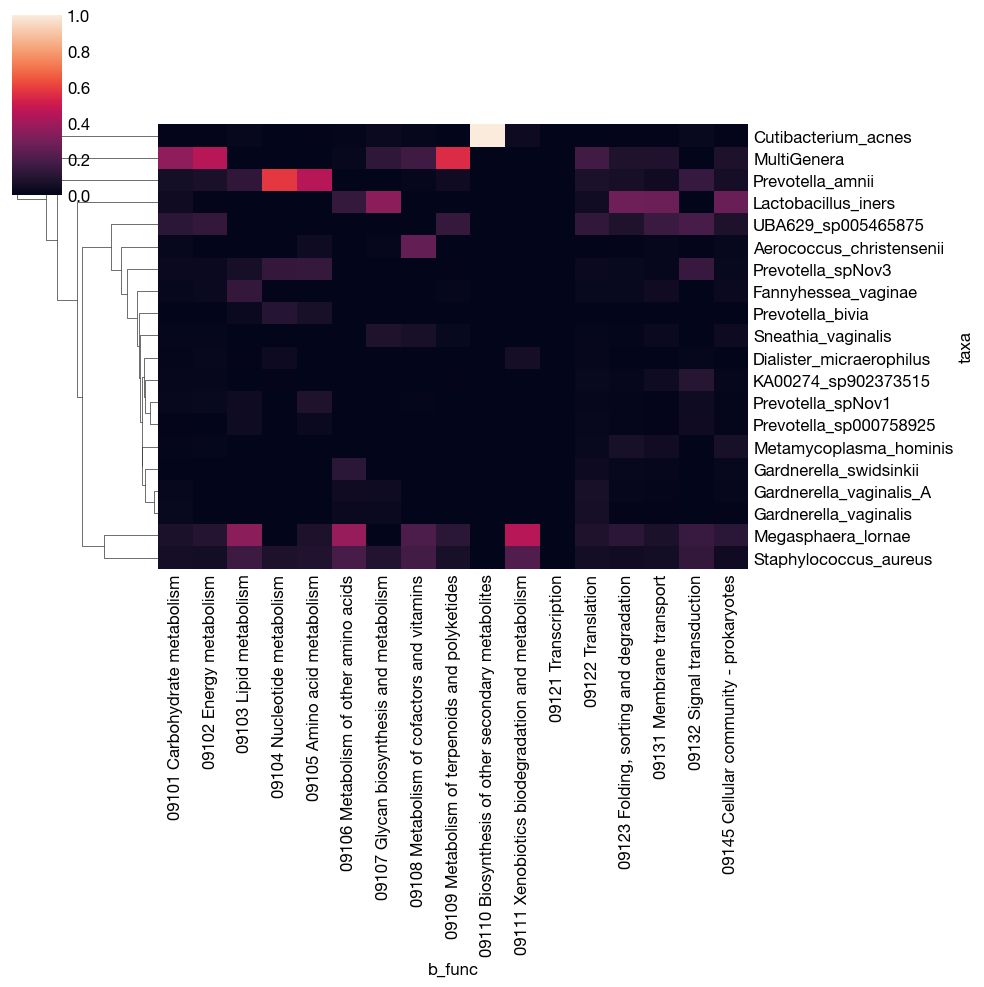

In [72]:
axs = [ax4_3, ax4_4]

ax_pos = 0
num_to_plot = 20
for g in ['tp2', 'tp1']:
    ax = axs[ax_pos]

    #get the data for this group
    plot_data =  data_func_taxas[data_func_taxas['group'] == g]
    plot_data['sum'] = plot_data.sum(axis=1, numeric_only=True)
    plot_data = plot_data.sort_values(by='sum', ascending=False)[0:num_to_plot]

    plot_data = sns.clustermap(plot_data.set_index('taxa').iloc[:,1:-1], col_cluster=False).data2d

    sns.heatmap(plot_data.T, ax=ax, cmap=my_cmap, linewidths=0.3, linecolor='#d4d2d3', xticklabels=True, yticklabels=True)
    
    ax.set_xlabel('')
    ax.set_ylabel('')

    ax.set_xticklabels([format_taxa_name(l.get_text()) for l in ax.get_xticklabels()], fontsize=6.25)

    ax.collections[0].colorbar.remove()

    ax_pos += 1


axs[1].set_yticklabels(['' for _ in axs[1].get_yticklabels()])
axs[0].set_yticklabels([' '.join(l.get_text().split(' ')[1:]) for l in axs[0].get_yticklabels()], fontsize=6.25)

axs[0].set_title('Timepoint 2', fontsize=10)
axs[1].set_title('Timepoint 1', fontsize=10)

## Add Legends

In [73]:
# functions legend
patch_list = []
for func, color in b_level_colors.items():
    data_key = mpatches.Patch(color=color,label=func)
    patch_list.append(data_key)

patch_list.append(mpatches.Patch(color=fdr_palette[False],label='FDR > 0.05'))

func_legend_ax.legend(handles=patch_list,ncol=1,fontsize=8, loc=(0,0), bbox_to_anchor=(0,0.2,1,1), frameon=False)
func_legend_ax.set_axis_off()

# color bar
fig.colorbar(plt.cm.ScalarMappable(norm= plt.Normalize(vmin=0, vmax=1), cmap=my_cmap),
                  cax=cbar_ax, orientation='vertical')
cbar_ax.set_yticklabels(cbar_ax.get_yticklabels(), fontsize=8)
cbar_ax.text(x=-1.1981, y=0.5, s='Relative Contribution', rotation=90, va='center')

/var/folders/vp/356zt1yd5qjbvk0d8hn5hmkh0000gp/T/ipykernel_24060/1053911640.py:15: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar_ax.set_yticklabels(cbar_ax.get_yticklabels(), fontsize=8)


Text(-1.1981, 0.5, 'Relative Contribution')

## Add Figure Labels

In [74]:
labels = ['A', 'B', 'C', 'D']
for ax in [a_ax, b_ax, c_ax, d_ax]:
    ax.text(x=0,y=0,s=labels.pop(0),fontsize=24, weight='bold')
    ax.set_axis_off()

## Save Figure

In [75]:
fig.savefig('fig3.1.pdf', format='pdf', bbox_inches='tight')

feat NOT subset; don't know how to subset; dropped
fond NOT subset; don't know how to subset; dropped
morx NOT subset; don't know how to subset; dropped
